In [2]:
import pandas as pd
import numpy as np
import os
import zipfile

print("Setup complete")

Setup complete


In [3]:
import zipfile
import os

zip_path = "/content/Zidio_FORESIGHT_Kaggle_Split_Dataset.zip"
extract_path = "/content/foresight_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [4]:
for root, dirs, files in os.walk("/content/foresight_data"):
    for file in files:
        print(os.path.join(root, file))

/content/foresight_data/sales_daily.csv
/content/foresight_data/sku_master.csv
/content/foresight_data/inventory_snapshots.csv
/content/foresight_data/calendar.csv


In [5]:
sales_path = "/content/foresight_data/sales_daily.csv"

sales = pd.read_csv(
    sales_path,
    usecols=["date", "sku", "units_sold", "revenue", "price", "promo_flag"]
)

sales["date"] = pd.to_datetime(sales["date"])

print("Sales shape:", sales.shape)
print(sales.head())

Sales shape: (73100, 6)
        date    sku  units_sold  revenue  price  promo_flag
0 2022-01-01  P0001         127  4254.50  33.50           1
1 2022-01-01  P0002         150  9451.50  63.01           1
2 2022-01-01  P0003          65  1819.35  27.99           1
3 2022-01-01  P0004          61  1995.92  32.72           1
4 2022-01-01  P0005          14  1030.96  73.64           0


In [6]:
daily_sales = (
    sales.groupby("date", as_index=False)["units_sold"]
    .sum()
    .sort_values("date")
)

daily_sales = daily_sales.rename(columns={
    "units_sold": "demand"
})

print("Daily sales shape:", daily_sales.shape)
print(daily_sales.head())
print(daily_sales.tail())

Daily sales shape: (731, 2)
        date  demand
0 2022-01-01   14484
1 2022-01-02   13415
2 2022-01-03   13681
3 2022-01-04   14084
4 2022-01-05   12572
          date  demand
726 2023-12-28   16271
727 2023-12-29   13368
728 2023-12-30   13156
729 2023-12-31   11208
730 2024-01-01   13244


In [7]:
print("Total demand:", daily_sales["demand"].sum())
print("Average daily demand:", daily_sales["demand"].mean())
print("Minimum daily demand:", daily_sales["demand"].min())
print("Maximum daily demand:", daily_sales["demand"].max())

Total demand: 9975582
Average daily demand: 13646.487004103967
Minimum daily demand: 10642
Maximum daily demand: 17239


Daily Demand Trend

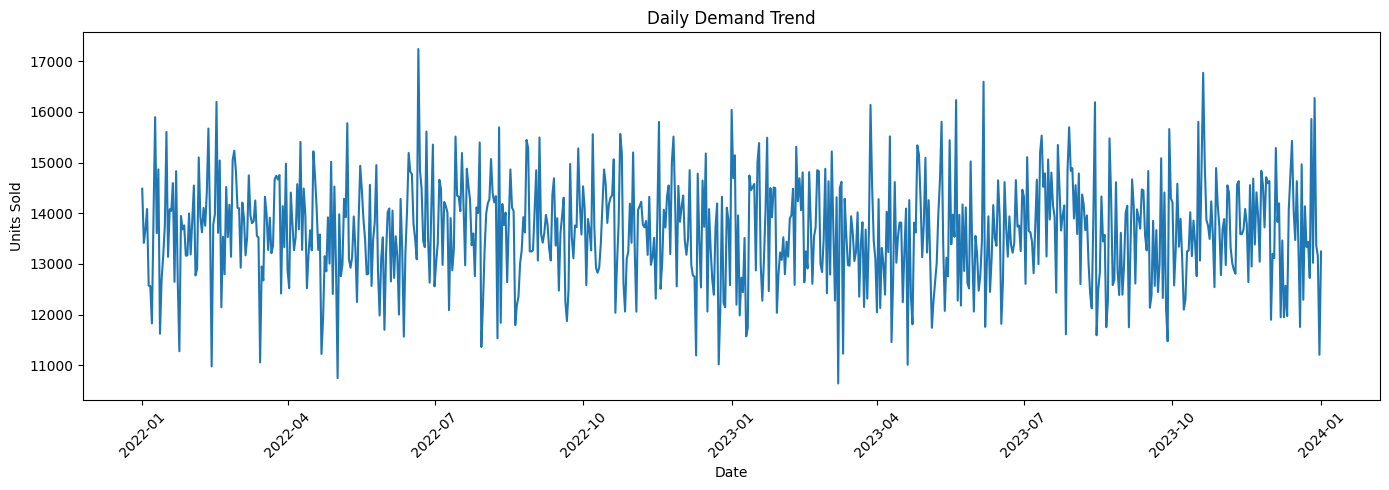

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["demand"]
)

plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
!pip install prophet -q

In [10]:
prophet_data = daily_sales[["date", "demand"]].copy()

prophet_data = prophet_data.rename(columns={
    "date": "ds",
    "demand": "y"
})

print(prophet_data.head())
print(prophet_data.shape)

          ds      y
0 2022-01-01  14484
1 2022-01-02  13415
2 2022-01-03  13681
3 2022-01-04  14084
4 2022-01-05  12572
(731, 2)


In [11]:
prophet_data = daily_sales[["date", "demand"]].copy()

prophet_data = prophet_data.rename(columns={
    "date": "ds",
    "demand": "y"
})

print(prophet_data.head())
print("\nShape:", prophet_data.shape)
print("\nDate range:", prophet_data["ds"].min(), "to", prophet_data["ds"].max())

          ds      y
0 2022-01-01  14484
1 2022-01-02  13415
2 2022-01-03  13681
3 2022-01-04  14084
4 2022-01-05  12572

Shape: (731, 2)

Date range: 2022-01-01 00:00:00 to 2024-01-01 00:00:00


In [12]:
# Time-series train/test split

test_days = 30

train = prophet_data.iloc[:-test_days].copy()
test = prophet_data.iloc[-test_days:].copy()

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("\nTraining period:")
print(train["ds"].min(), "to", train["ds"].max())

print("\nTesting period:")
print(test["ds"].min(), "to", test["ds"].max())

Training data: (701, 2)
Testing data: (30, 2)

Training period:
2022-01-01 00:00:00 to 2023-12-02 00:00:00

Testing period:
2023-12-03 00:00:00 to 2024-01-01 00:00:00


In [13]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

print("Prophet model trained successfully!")

Prophet model trained successfully!


In [14]:
# Create future dates for the test period
future = model.make_future_dataframe(
    periods=30,
    freq="D"
)

# Generate forecast
forecast = model.predict(future)

# Keep only the test-period predictions
forecast_test = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)

print(forecast_test.head())
print("\nForecast shape:", forecast_test.shape)

            ds          yhat    yhat_lower    yhat_upper
701 2023-12-03  13805.304947  12580.112973  15006.080134
702 2023-12-04  13566.041400  12263.017707  14849.175552
703 2023-12-05  13725.240261  12498.189560  15039.617703
704 2023-12-06  13590.413216  12295.165229  14843.421938
705 2023-12-07  13619.138489  12310.253456  14942.749591

Forecast shape: (30, 4)


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Merge actual test values with forecast
results = test.merge(
    forecast_test,
    left_on="ds",
    right_on="ds",
    how="left"
)

# Calculate metrics
mae = mean_absolute_error(results["y"], results["yhat"])
rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

# MAPE
mape = np.mean(
    np.abs((results["y"] - results["yhat"]) / results["y"])
) * 100

print("Prophet Model Performance")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

Prophet Model Performance
-------------------------
MAE  : 1007.34
RMSE : 1293.18
MAPE : 7.32%


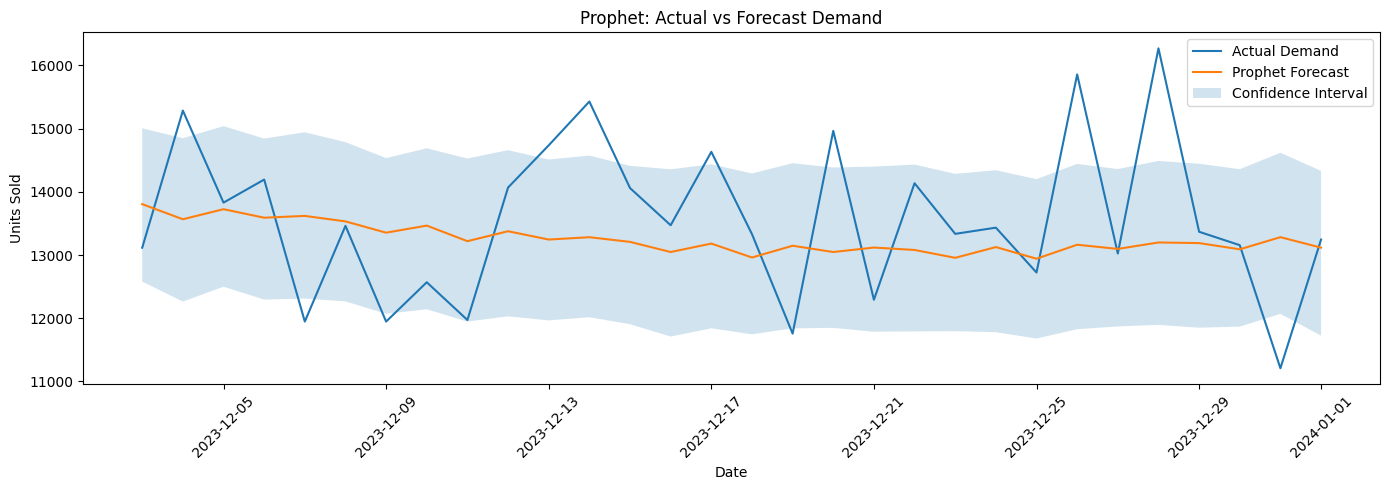

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    results["ds"],
    results["y"],
    label="Actual Demand"
)

plt.plot(
    results["ds"],
    results["yhat"],
    label="Prophet Forecast"
)

plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Prophet: Actual vs Forecast Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

SARMA model

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARMA/SARIMA training series
train_series = train.set_index("ds")["y"]

# Fit seasonal ARIMA model with weekly seasonality
sarima_model = SARIMAX(
    train_series,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print("SARMA/SARIMA model trained successfully!")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARMA/SARIMA model trained successfully!


In [18]:
# Forecast the next 30 days
sarima_forecast = sarima_result.forecast(steps=30)

# Create results dataframe
sarima_results = pd.DataFrame({
    "ds": test["ds"].values,
    "actual": test["y"].values,
    "forecast": sarima_forecast.values
})

# Calculate metrics
sarima_mae = mean_absolute_error(
    sarima_results["actual"],
    sarima_results["forecast"]
)

sarima_rmse = np.sqrt(mean_squared_error(
    sarima_results["actual"],
    sarima_results["forecast"]
))

sarima_mape = np.mean(
    np.abs(
        (sarima_results["actual"] - sarima_results["forecast"])
        / sarima_results["actual"]
    )
) * 100

print("SARMA/SARIMA Model Performance")
print("------------------------------")
print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

SARMA/SARIMA Model Performance
------------------------------
MAE  : 988.44
RMSE : 1233.80
MAPE : 7.34%


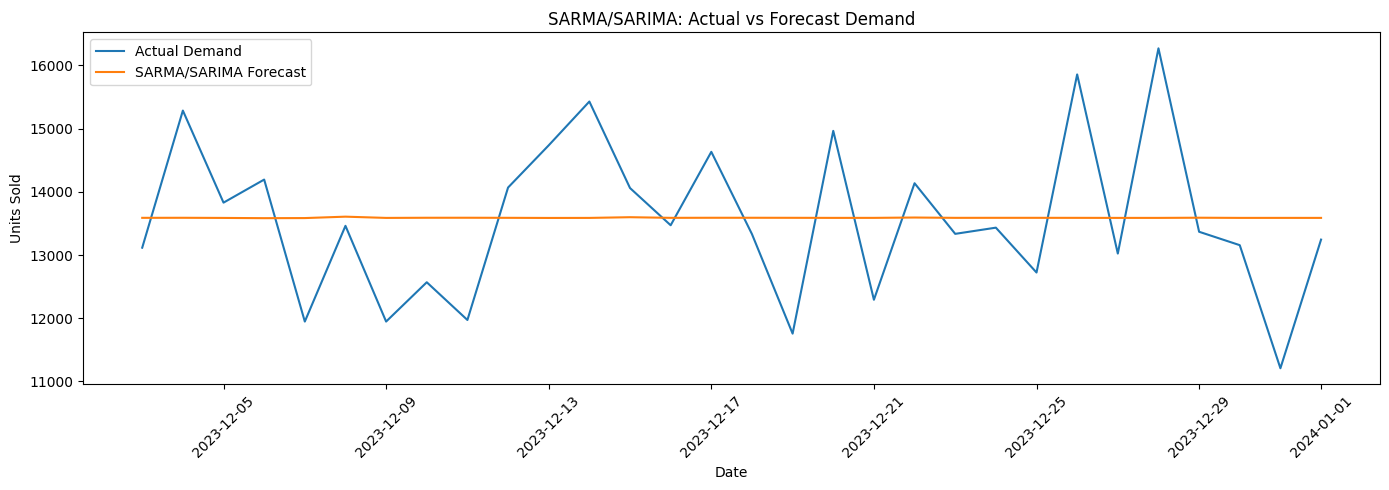

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    sarima_results["ds"],
    sarima_results["actual"],
    label="Actual Demand"
)

plt.plot(
    sarima_results["ds"],
    sarima_results["forecast"],
    label="SARMA/SARIMA Forecast"
)

plt.title("SARMA/SARIMA: Actual vs Forecast Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

LSTM

In [20]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [21]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Convert demand into numpy array
train_values = train["y"].values.reshape(-1, 1)
test_values = test["y"].values.reshape(-1, 1)

# Scale using ONLY training data
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_values)

# Combine train + test for creating test sequences
all_values = np.concatenate([train_values, test_values])
all_scaled = scaler.transform(all_values)

# Number of previous days used to predict the next day
lookback = 30

X_train = []
y_train = []

for i in range(lookback, len(train_scaled)):
    X_train.append(train_scaled[i-lookback:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape for LSTM:
# samples, time steps, features
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (671, 30, 1)
y_train shape: (671,)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(30, 1)),
    Dropout(0.2),

    LSTM(50),
    Dropout(0.2),

    Dense(25),
    Dense(1)
])

# Compile
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# Train
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

print("LSTM model trained successfully!")

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0521 - val_loss: 0.0216
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0273 - val_loss: 0.0222
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0256 - val_loss: 0.0239
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0256 - val_loss: 0.0215
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0261 - val_loss: 0.0212
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0263 - val_loss: 0.0212
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0259 - val_loss: 0.0213
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0257 - val_loss: 0.0221
Epoch 9/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0257 - val_loss: 0.0209
Epoch 10/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0257 - val_loss: 0.0239
Epoch 11/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0247 - val_loss: 0.0212
Epoch 12/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0253 - val_l

In [23]:
# Prepare test sequences

test_input = all_scaled[len(train_scaled) - lookback:]

X_test = []

for i in range(lookback, len(test_input)):
    X_test.append(test_input[i-lookback:i, 0])

X_test = np.array(X_test)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_test shape:", X_test.shape)

# Predict
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)

# Convert predictions back to original demand scale
lstm_predictions = scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

print("Predictions generated:", len(lstm_predictions))

X_test shape: (30, 30, 1)
Predictions generated: 30


In [24]:
# LSTM evaluation

lstm_actual = test["y"].values

lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_predictions
    )
)

lstm_mape = np.mean(
    np.abs(
        (lstm_actual - lstm_predictions)
        / lstm_actual
    )
) * 100

print("LSTM Model Performance")
print("----------------------")
print(f"MAE  : {lstm_mae:.2f}")
print(f"RMSE : {lstm_rmse:.2f}")
print(f"MAPE : {lstm_mape:.2f}%")

LSTM Model Performance
----------------------
MAE  : 980.22
RMSE : 1235.71
MAPE : 7.26%


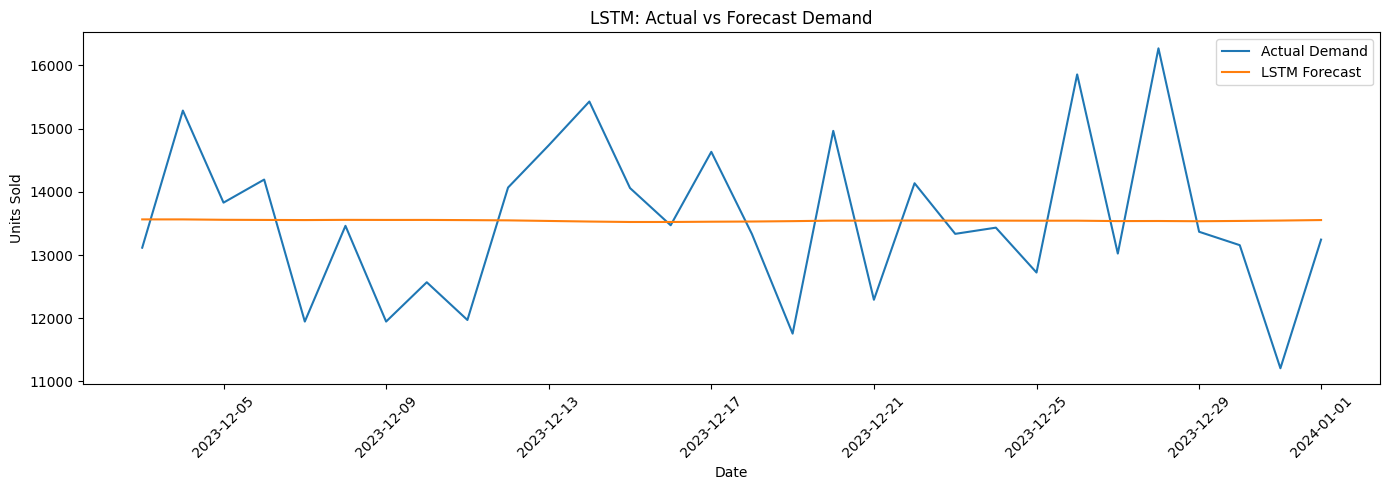

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    test["ds"],
    lstm_actual,
    label="Actual Demand"
)

plt.plot(
    test["ds"],
    lstm_predictions,
    label="LSTM Forecast"
)

plt.title("LSTM: Actual vs Forecast Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Model Comparison Tabel

In [26]:
# Model comparison

model_comparison = pd.DataFrame({
    "Model": ["Prophet", "SARMA/SARIMA", "LSTM"],
    "MAE": [mae, sarima_mae, lstm_mae],
    "RMSE": [rmse, sarima_rmse, lstm_rmse],
    "MAPE (%)": [mape, sarima_mape, lstm_mape]
})

model_comparison = model_comparison.sort_values(
    by="MAE"
).reset_index(drop=True)

print(model_comparison)

          Model          MAE         RMSE  MAPE (%)
0          LSTM   980.224426  1235.713205  7.256857
1  SARMA/SARIMA   988.439235  1233.797822  7.340718
2       Prophet  1007.336200  1293.184993  7.321486


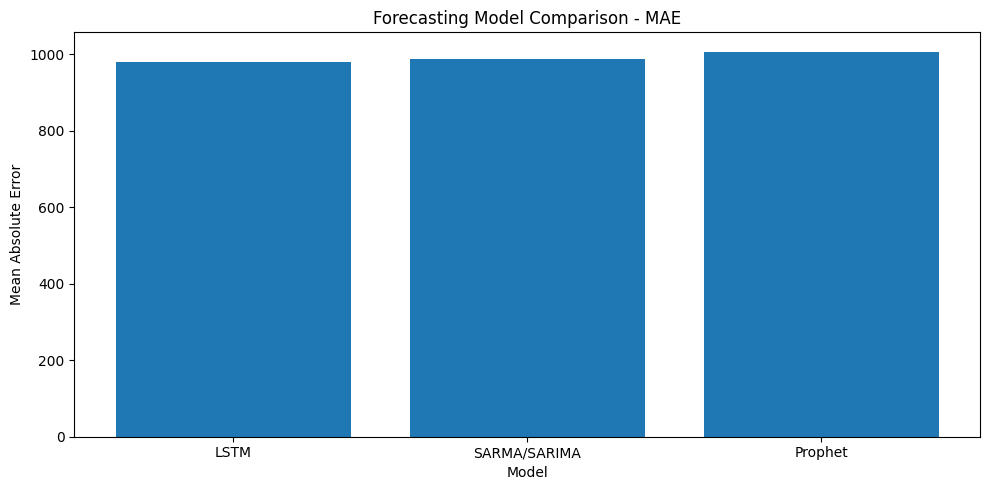

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Forecasting Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.tight_layout()
plt.show()

In [28]:
# Train final SARIMA model on the complete dataset

full_series = prophet_data.set_index("ds")["y"]

final_sarima = SARIMAX(
    full_series,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_result = final_sarima.fit(disp=False)

print("Final SARIMA model trained on full dataset.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Final SARIMA model trained on full dataset.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
# Forecast next 30 days

future_forecast = final_sarima_result.forecast(steps=30)

last_date = full_series.index.max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_demand = pd.DataFrame({
    "date": future_dates,
    "forecast_demand": future_forecast.values
})

print(future_demand)

         date  forecast_demand
0  2024-01-02     13576.018009
1  2024-01-03     13575.452186
2  2024-01-04     13574.600117
3  2024-01-05     13577.239162
4  2024-01-06     13577.422784
5  2024-01-07     13578.913767
6  2024-01-08     13577.580212
7  2024-01-09     13574.894364
8  2024-01-10     13574.417226
9  2024-01-11     13573.727411
10 2024-01-12     13575.631448
11 2024-01-13     13575.711139
12 2024-01-14     13576.762183
13 2024-01-15     13575.714635
14 2024-01-16     13573.662354
15 2024-01-17     13573.251114
16 2024-01-18     13572.681859
17 2024-01-19     13574.039800
18 2024-01-20     13574.042279
19 2024-01-21     13574.766461
20 2024-01-22     13573.931419
21 2024-01-23     13572.349875
22 2024-01-24     13571.987603
23 2024-01-25     13571.507928
24 2024-01-26     13572.460135
25 2024-01-27     13572.405253
26 2024-01-28     13572.886587
27 2024-01-29     13572.209440
28 2024-01-30     13570.977654
29 2024-01-31     13570.651771


In [30]:
# Average daily demand for each SKU

sku_demand = (
    sales.groupby("sku")["units_sold"]
    .mean()
    .reset_index()
)

sku_demand = sku_demand.rename(columns={
    "units_sold": "avg_daily_demand"
})

print(sku_demand.head())
print("Number of SKUs:", len(sku_demand))

     sku  avg_daily_demand
0  P0001        136.268399
1  P0002        133.468399
2  P0003        134.960055
3  P0004        135.567989
4  P0005        137.796990
Number of SKUs: 20


In [31]:
# Load only required inventory columns

inventory_path = "/content/foresight_data/inventory_snapshots.csv"

inventory = pd.read_csv(
    inventory_path,
    usecols=[
        "snapshot_date",
        "sku",
        "on_hand",
        "on_order",
        "lead_time_days",
        "reorder_point"
    ]
)

inventory["snapshot_date"] = pd.to_datetime(inventory["snapshot_date"])

print("Inventory shape:", inventory.shape)
print(inventory.head())

Inventory shape: (73100, 6)
  snapshot_date    sku  on_hand  on_order  lead_time_days  reorder_point
0    2022-01-01  P0001      231        55               7             69
1    2022-01-01  P0002      204        66               7             61
2    2022-01-01  P0003      102        51               7             31
3    2022-01-01  P0004      469       164               7            141
4    2022-01-01  P0005      166       135               7             50


In [32]:
# Get the latest inventory snapshot for each SKU

latest_inventory = (
    inventory.sort_values("snapshot_date")
    .groupby("sku")
    .tail(1)
    .reset_index(drop=True)
)

print("Latest inventory shape:", latest_inventory.shape)
print(latest_inventory)

Latest inventory shape: (20, 6)
   snapshot_date    sku  on_hand  on_order  lead_time_days  reorder_point
0     2024-01-01  P0005      411       200               7            123
1     2024-01-01  P0004      415        79               7            124
2     2024-01-01  P0003      112       169               7             34
3     2024-01-01  P0002      388       102               7            116
4     2024-01-01  P0001      138        65               7             41
5     2024-01-01  P0019      409        49               7            123
6     2024-01-01  P0018      151       147               7             45
7     2024-01-01  P0017      236        91               7             71
8     2024-01-01  P0015      433       190               7            130
9     2024-01-01  P0014      342       171               7            103
10    2024-01-01  P0013      472       160               7            142
11    2024-01-01  P0012      193       115               7             58
12    

Days of Stock + Stockout Risk

In [33]:
# Combine latest inventory with average SKU demand

inventory_risk = latest_inventory.merge(
    sku_demand,
    on="sku",
    how="left"
)

# Calculate days of stock
inventory_risk["days_of_stock"] = (
    inventory_risk["on_hand"] /
    inventory_risk["avg_daily_demand"]
)

# Calculate demand during lead time
inventory_risk["lead_time_demand"] = (
    inventory_risk["avg_daily_demand"] *
    inventory_risk["lead_time_days"]
)

# Stockout risk classification
def classify_risk(row):
    if row["days_of_stock"] <= row["lead_time_days"]:
        return "High Risk"
    elif row["days_of_stock"] <= row["lead_time_days"] + 7:
        return "Medium Risk"
    else:
        return "Low Risk"

inventory_risk["stockout_risk"] = inventory_risk.apply(
    classify_risk,
    axis=1
)

print(
    inventory_risk[
        [
            "sku",
            "on_hand",
            "avg_daily_demand",
            "days_of_stock",
            "lead_time_days",
            "lead_time_demand",
            "stockout_risk"
        ]
    ].sort_values("days_of_stock")
)

      sku  on_hand  avg_daily_demand  days_of_stock  lead_time_days  \
16  P0007       53        136.613133       0.387957               7   
14  P0009       62        137.369631       0.451337               7   
2   P0003      112        134.960055       0.829875               7   
19  P0020      117        138.907798       0.842285               7   
4   P0001      138        136.268399       1.012707               7   
6   P0018      151        134.760876       1.120503               7   
12  P0011      156        136.624350       1.141817               7   
17  P0006      160        136.013953       1.176350               7   
11  P0012      193        134.519836       1.434733               7   
15  P0008      218        133.669767       1.630885               7   
7   P0017      236        136.938440       1.723402               7   
18  P0016      258        139.116826       1.854556               7   
9   P0014      342        138.884268       2.462482               7   
3   P0

In [34]:
# Improved stockout analysis

inventory_risk["available_inventory"] = (
    inventory_risk["on_hand"] +
    inventory_risk["on_order"]
)

inventory_risk["coverage_days"] = (
    inventory_risk["available_inventory"] /
    inventory_risk["avg_daily_demand"]
)

def classify_stockout_risk(row):
    if row["coverage_days"] < row["lead_time_days"]:
        return "Critical"
    elif row["coverage_days"] < row["lead_time_days"] + 3:
        return "High"
    elif row["coverage_days"] < row["lead_time_days"] + 7:
        return "Medium"
    else:
        return "Low"

inventory_risk["risk_level"] = inventory_risk.apply(
    classify_stockout_risk,
    axis=1
)

print(
    inventory_risk[
        [
            "sku",
            "on_hand",
            "on_order",
            "available_inventory",
            "avg_daily_demand",
            "coverage_days",
            "lead_time_days",
            "risk_level"
        ]
    ].sort_values("coverage_days")
)

      sku  on_hand  on_order  available_inventory  avg_daily_demand  \
16  P0007       53        40                   93        136.613133   
4   P0001      138        65                  203        136.268399   
17  P0006      160        78                  238        136.013953   
14  P0009       62       183                  245        137.369631   
19  P0020      117       165                  282        138.907798   
2   P0003      112       169                  281        134.960055   
6   P0018      151       147                  298        134.760876   
11  P0012      193       115                  308        134.519836   
12  P0011      156       166                  322        136.624350   
7   P0017      236        91                  327        136.938440   
15  P0008      218       144                  362        133.669767   
18  P0016      258       197                  455        139.116826   
5   P0019      409        49                  458        136.224077   
13  P0

In [35]:
def classify_stockout_risk(row):
    coverage = row["coverage_days"]
    lead_time = row["lead_time_days"]

    if coverage < 0.50 * lead_time:
        return "Critical"
    elif coverage < 0.75 * lead_time:
        return "High"
    elif coverage < lead_time:
        return "Medium"
    else:
        return "Low"

inventory_risk["risk_level"] = inventory_risk.apply(
    classify_stockout_risk,
    axis=1
)

print(
    inventory_risk[
        [
            "sku",
            "available_inventory",
            "avg_daily_demand",
            "coverage_days",
            "lead_time_days",
            "risk_level"
        ]
    ].sort_values("coverage_days")
)

      sku  available_inventory  avg_daily_demand  coverage_days  \
16  P0007                   93        136.613133       0.680754   
4   P0001                  203        136.268399       1.489707   
17  P0006                  238        136.013953       1.749820   
14  P0009                  245        137.369631       1.783509   
19  P0020                  282        138.907798       2.030124   
2   P0003                  281        134.960055       2.082098   
6   P0018                  298        134.760876       2.211324   
11  P0012                  308        134.519836       2.289625   
12  P0011                  322        136.624350       2.356827   
7   P0017                  327        136.938440       2.387934   
15  P0008                  362        133.669767       2.708167   
18  P0016                  455        139.116826       3.270632   
5   P0019                  458        136.224077       3.362108   
13  P0010                  477        135.832832       3.51166

 14 days of demand

In [36]:
# Overstock analysis

target_days = 14

inventory_risk["target_inventory"] = (
    inventory_risk["avg_daily_demand"] * target_days
)

inventory_risk["excess_inventory"] = (
    inventory_risk["available_inventory"]
    - inventory_risk["target_inventory"]
)

inventory_risk["excess_inventory"] = (
    inventory_risk["excess_inventory"].clip(lower=0)
)

def classify_overstock(excess):
    if excess > 0:
        return "Overstock"
    else:
        return "Healthy"

inventory_risk["overstock_status"] = (
    inventory_risk["excess_inventory"]
    .apply(classify_overstock)
)

print(
    inventory_risk[
        [
            "sku",
            "available_inventory",
            "avg_daily_demand",
            "target_inventory",
            "excess_inventory",
            "overstock_status"
        ]
    ].sort_values("excess_inventory", ascending=False)
)

      sku  available_inventory  avg_daily_demand  target_inventory  \
0   P0005                  611        137.796990       1929.157866   
1   P0004                  494        135.567989       1897.951847   
2   P0003                  281        134.960055       1889.440766   
3   P0002                  490        133.468399       1868.557592   
4   P0001                  203        136.268399       1907.757592   
5   P0019                  458        136.224077       1907.137073   
6   P0018                  298        134.760876       1886.652257   
7   P0017                  327        136.938440       1917.138167   
8   P0015                  623        138.791518       1943.081259   
9   P0014                  513        138.884268       1944.379754   
10  P0013                  632        136.968263       1917.555677   
11  P0012                  308        134.519836       1883.277702   
12  P0011                  322        136.624350       1912.740903   
13  P0010           

Historical Inventory Data Baseline

In [37]:
# Historical average inventory by SKU

historical_inventory = (
    inventory.groupby("sku")
    .agg(
        avg_on_hand=("on_hand", "mean"),
        max_on_hand=("on_hand", "max"),
        min_on_hand=("on_hand", "min")
    )
    .reset_index()
)

# Merge with current inventory
inventory_analysis = inventory_risk.merge(
    historical_inventory,
    on="sku",
    how="left"
)

# Difference between current and historical average
inventory_analysis["inventory_vs_average"] = (
    inventory_analysis["on_hand"]
    - inventory_analysis["avg_on_hand"]
)

inventory_analysis["inventory_ratio"] = (
    inventory_analysis["on_hand"]
    / inventory_analysis["avg_on_hand"]
)

print(
    inventory_analysis[
        [
            "sku",
            "on_hand",
            "avg_on_hand",
            "max_on_hand",
            "min_on_hand",
            "inventory_vs_average",
            "inventory_ratio"
        ]
    ].sort_values("inventory_ratio", ascending=False)
)

      sku  on_hand  avg_on_hand  max_on_hand  min_on_hand  \
10  P0013      472   275.111354          500           50   
8   P0015      433   276.408208          500           50   
1   P0004      415   271.556498          500           50   
13  P0010      419   274.922572          500           50   
0   P0005      411   273.041860          500           50   
5   P0019      409   274.525308          500           50   
3   P0002      388   271.146101          500           50   
9   P0014      342   277.892202          500           50   
18  P0016      258   277.505062          500           50   
7   P0017      236   278.320930          500           50   
15  P0008      218   272.774829          500           50   
11  P0012      193   272.511902          500           50   
17  P0006      160   273.571272          500           50   
12  P0011      156   272.807661          500           50   
6   P0018      151   272.538714          500           50   
4   P0001      138   272

In [38]:
def classify_overstock_ratio(ratio):
    if ratio >= 1.40:
        return "High Overstock"
    elif ratio >= 1.20:
        return "Moderate Overstock"
    elif ratio >= 0.80:
        return "Normal"
    else:
        return "Low Inventory"

inventory_analysis["overstock_status"] = (
    inventory_analysis["inventory_ratio"]
    .apply(classify_overstock_ratio)
)

print(
    inventory_analysis[
        [
            "sku",
            "on_hand",
            "avg_on_hand",
            "inventory_ratio",
            "overstock_status"
        ]
    ].sort_values("inventory_ratio", ascending=False)
)

print("\nStatus Summary:")
print(inventory_analysis["overstock_status"].value_counts())

      sku  on_hand  avg_on_hand  inventory_ratio    overstock_status
10  P0013      472   275.111354         1.715669      High Overstock
8   P0015      433   276.408208         1.566524      High Overstock
1   P0004      415   271.556498         1.528227      High Overstock
13  P0010      419   274.922572         1.524065      High Overstock
0   P0005      411   273.041860         1.505264      High Overstock
5   P0019      409   274.525308         1.489844      High Overstock
3   P0002      388   271.146101         1.430963      High Overstock
9   P0014      342   277.892202         1.230693  Moderate Overstock
18  P0016      258   277.505062         0.929713              Normal
7   P0017      236   278.320930         0.847942              Normal
15  P0008      218   272.774829         0.799194       Low Inventory
11  P0012      193   272.511902         0.708226       Low Inventory
17  P0006      160   273.571272         0.584857       Low Inventory
12  P0011      156   272.807661   

In [38]:
# Load only required SKU cost information

sku_path = "/content/foresight_data/sku_master.csv"

sku_cost = pd.read_csv(
    sku_path,
    usecols=["sku", "unit_cost"]
)

print("SKU cost data:", sku_cost.shape)
print(sku_cost.head())

SKU cost data: (70223, 2)
     sku  unit_cost
0  P0001      21.78
1  P0002      40.96
2  P0003      18.19
3  P0004      21.27
4  P0005      47.87


In [39]:
# Merge unit cost with inventory analysis

inventory_analysis = inventory_analysis.merge(
    sku_cost,
    on="sku",
    how="left"
)

# Current inventory value
inventory_analysis["inventory_value"] = (
    inventory_analysis["on_hand"] *
    inventory_analysis["unit_cost"]
)

# Historical average inventory value
inventory_analysis["avg_inventory_value"] = (
    inventory_analysis["avg_on_hand"] *
    inventory_analysis["unit_cost"]
)

# Estimated excess capital
inventory_analysis["excess_capital"] = (
    inventory_analysis["inventory_value"] -
    inventory_analysis["avg_inventory_value"]
).clip(lower=0)

print(
    inventory_analysis[
        [
            "sku",
            "on_hand",
            "unit_cost",
            "inventory_value",
            "avg_inventory_value",
            "excess_capital",
            "overstock_status"
        ]
    ].sort_values(
        "excess_capital",
        ascending=False
    )
)

         sku  on_hand  unit_cost  inventory_value  avg_inventory_value  \
37357  P0013      472      64.97         30665.84         17873.984689   
38571  P0013      472      64.92         30642.24         17860.229122   
37178  P0013      472      64.90         30632.80         17854.726895   
38511  P0013      472      64.85         30609.20         17840.971327   
35704  P0013      472      64.84         30604.48         17838.220213   
...      ...      ...        ...              ...                  ...   
41738  P0012      193      34.16          6592.88          9309.006555   
41737  P0012      193      14.01          2703.93          3817.891740   
41736  P0012      193       8.35          1611.55          2275.474378   
41735  P0012      193      41.61          8030.73         11339.220222   
41713  P0012      193      11.26          2173.18          3068.484011   

       excess_capital overstock_status  
37357    12791.855311          Healthy  
38571    12782.010878        

In [40]:
print("Total Inventory Value:",
      inventory_analysis["inventory_value"].sum())

print("Estimated Excess Capital:",
      inventory_analysis["excess_capital"].sum())

print("Average Inventory Value:",
      inventory_analysis["avg_inventory_value"].sum())

Total Inventory Value: 646933986.33
Estimated Excess Capital: 137662228.75680164
Average Inventory Value: 690716867.1595377


In [41]:
# Create ONE unit cost per SKU
sku_cost_unique = (
    sku_cost
    .groupby("sku", as_index=False)["unit_cost"]
    .mean()
)

print("Unique SKU cost rows:", sku_cost_unique.shape)
print(sku_cost_unique.head())

Unique SKU cost rows: (20, 2)
     sku  unit_cost
0  P0001  35.522342
1  P0002  35.860375
2  P0003  35.658487
3  P0004  36.105430
4  P0005  35.761012


In [42]:
# Remove the incorrect cost columns if they exist
inventory_analysis = inventory_analysis.drop(
    columns=[
        "unit_cost",
        "inventory_value",
        "avg_inventory_value",
        "excess_capital"
    ],
    errors="ignore"
)

# Merge ONE cost per SKU
inventory_analysis = inventory_analysis.merge(
    sku_cost_unique,
    on="sku",
    how="left"
)

# Calculate current inventory value
inventory_analysis["inventory_value"] = (
    inventory_analysis["on_hand"] *
    inventory_analysis["unit_cost"]
)

# Historical average inventory value
inventory_analysis["avg_inventory_value"] = (
    inventory_analysis["avg_on_hand"] *
    inventory_analysis["unit_cost"]
)

# Excess capital only for inventory above historical average
inventory_analysis["excess_capital"] = (
    inventory_analysis["inventory_value"]
    - inventory_analysis["avg_inventory_value"]
).clip(lower=0)

print("Rows:", len(inventory_analysis))

print(
    inventory_analysis[
        [
            "sku",
            "on_hand",
            "unit_cost",
            "inventory_value",
            "excess_capital",
            "overstock_status"
        ]
    ].sort_values(
        "excess_capital",
        ascending=False
    )
)

Rows: 70223
         sku  on_hand  unit_cost  inventory_value  excess_capital  \
38626  P0013      472  35.756507     16877.071168     7040.050181   
38627  P0013      472  35.756507     16877.071168     7040.050181   
38628  P0013      472  35.756507     16877.071168     7040.050181   
38629  P0013      472  35.756507     16877.071168     7040.050181   
38630  P0013      472  35.756507     16877.071168     7040.050181   
...      ...      ...        ...              ...             ...   
70207  P0020      117  36.112195      4225.126821        0.000000   
70206  P0020      117  36.112195      4225.126821        0.000000   
70205  P0020      117  36.112195      4225.126821        0.000000   
70204  P0020      117  36.112195      4225.126821        0.000000   
70203  P0020      117  36.112195      4225.126821        0.000000   

      overstock_status  
38626          Healthy  
38627          Healthy  
38628          Healthy  
38629          Healthy  
38630          Healthy  
...      

In [43]:
print("Total Inventory Value: ₹",
      round(inventory_analysis["inventory_value"].sum(), 2))

print("Estimated Excess Capital: ₹",
      round(inventory_analysis["excess_capital"].sum(), 2))

print("Average Inventory Value: ₹",
      round(inventory_analysis["avg_inventory_value"].sum(), 2))

Total Inventory Value: ₹ 646933986.33
Estimated Excess Capital: ₹ 137662228.76
Average Inventory Value: ₹ 690716867.16


In [44]:
# Rebuild inventory analysis from the original 20-row datasets

inventory_analysis = latest_inventory.merge(
    sku_demand,
    on="sku",
    how="left"
)

inventory_analysis["available_inventory"] = (
    inventory_analysis["on_hand"] +
    inventory_analysis["on_order"]
)

inventory_analysis["coverage_days"] = (
    inventory_analysis["available_inventory"] /
    inventory_analysis["avg_daily_demand"]
)

# Stockout risk
def classify_stockout_risk(row):
    coverage = row["coverage_days"]
    lead_time = row["lead_time_days"]

    if coverage < 0.50 * lead_time:
        return "Critical"
    elif coverage < 0.75 * lead_time:
        return "High"
    elif coverage < lead_time:
        return "Medium"
    else:
        return "Low"

inventory_analysis["risk_level"] = inventory_analysis.apply(
    classify_stockout_risk,
    axis=1
)

# Historical inventory baseline
inventory_analysis = inventory_analysis.merge(
    historical_inventory,
    on="sku",
    how="left"
)

# Overstock classification
inventory_analysis["inventory_ratio"] = (
    inventory_analysis["on_hand"] /
    inventory_analysis["avg_on_hand"]
)

def classify_overstock_ratio(ratio):
    if ratio >= 1.40:
        return "High Overstock"
    elif ratio >= 1.20:
        return "Moderate Overstock"
    elif ratio >= 0.80:
        return "Normal"
    else:
        return "Low Inventory"

inventory_analysis["overstock_status"] = (
    inventory_analysis["inventory_ratio"]
    .apply(classify_overstock_ratio)
)

print("Rows:", len(inventory_analysis))
print(inventory_analysis.head())

Rows: 20
  snapshot_date    sku  on_hand  on_order  lead_time_days  reorder_point  \
0    2024-01-01  P0005      411       200               7            123   
1    2024-01-01  P0004      415        79               7            124   
2    2024-01-01  P0003      112       169               7             34   
3    2024-01-01  P0002      388       102               7            116   
4    2024-01-01  P0001      138        65               7             41   

   avg_daily_demand  available_inventory  coverage_days risk_level  \
0        137.796990                  611       4.434059       High   
1        135.567989                  494       3.643928       High   
2        134.960055                  281       2.082098   Critical   
3        133.468399                  490       3.671281       High   
4        136.268399                  203       1.489707   Critical   

   avg_on_hand  max_on_hand  min_on_hand  inventory_ratio overstock_status  
0   273.041860          500         

In [45]:
# FRESH INVENTORY ANALYSIS — 20 SKUs ONLY

inventory_analysis = latest_inventory.merge(
    sku_demand,
    on="sku",
    how="left"
)

inventory_analysis["available_inventory"] = (
    inventory_analysis["on_hand"] +
    inventory_analysis["on_order"]
)

inventory_analysis["coverage_days"] = (
    inventory_analysis["available_inventory"] /
    inventory_analysis["avg_daily_demand"]
)

# Stockout risk
inventory_analysis["risk_level"] = inventory_analysis.apply(
    classify_stockout_risk,
    axis=1
)

# Historical inventory baseline
inventory_analysis = inventory_analysis.merge(
    historical_inventory,
    on="sku",
    how="left"
)

# Inventory ratio
inventory_analysis["inventory_ratio"] = (
    inventory_analysis["on_hand"] /
    inventory_analysis["avg_on_hand"]
)

# Overstock status
inventory_analysis["overstock_status"] = (
    inventory_analysis["inventory_ratio"]
    .apply(classify_overstock_ratio)
)

print("Rows:", len(inventory_analysis))
print(inventory_analysis.shape)
print(inventory_analysis.head())

Rows: 20
(20, 15)
  snapshot_date    sku  on_hand  on_order  lead_time_days  reorder_point  \
0    2024-01-01  P0005      411       200               7            123   
1    2024-01-01  P0004      415        79               7            124   
2    2024-01-01  P0003      112       169               7             34   
3    2024-01-01  P0002      388       102               7            116   
4    2024-01-01  P0001      138        65               7             41   

   avg_daily_demand  available_inventory  coverage_days risk_level  \
0        137.796990                  611       4.434059       High   
1        135.567989                  494       3.643928       High   
2        134.960055                  281       2.082098   Critical   
3        133.468399                  490       3.671281       High   
4        136.268399                  203       1.489707   Critical   

   avg_on_hand  max_on_hand  min_on_hand  inventory_ratio overstock_status  
0   273.041860          500

In [46]:
# Add one unit cost per SKU

inventory_analysis = inventory_analysis.merge(
    sku_cost_unique,
    on="sku",
    how="left"
)

print("Rows after cost merge:", len(inventory_analysis))
print(inventory_analysis[["sku", "on_hand", "unit_cost"]])

Rows after cost merge: 20
      sku  on_hand  unit_cost
0   P0005      411  35.761012
1   P0004      415  36.105430
2   P0003      112  35.658487
3   P0002      388  35.860375
4   P0001      138  35.522342
5   P0019      409  35.730564
6   P0018      151  35.633496
7   P0017      236  35.588991
8   P0015      433  35.612477
9   P0014      342  36.137570
10  P0013      472  35.756507
11  P0012      193  35.804086
12  P0011      156  36.619047
13  P0010      419  35.983964
14  P0009       62  35.847540
15  P0008      218  36.070661
16  P0007       53  35.732891
17  P0006      160  35.595685
18  P0016      258  35.613878
19  P0020      117  36.112195


In [47]:
# Calculate inventory value and excess capital

inventory_analysis["inventory_value"] = (
    inventory_analysis["on_hand"] *
    inventory_analysis["unit_cost"]
)

inventory_analysis["avg_inventory_value"] = (
    inventory_analysis["avg_on_hand"] *
    inventory_analysis["unit_cost"]
)

inventory_analysis["excess_capital"] = (
    inventory_analysis["inventory_value"]
    - inventory_analysis["avg_inventory_value"]
).clip(lower=0)

print(
    inventory_analysis[
        [
            "sku",
            "on_hand",
            "unit_cost",
            "inventory_value",
            "excess_capital",
            "overstock_status"
        ]
    ].sort_values(
        "excess_capital",
        ascending=False
    )
)

      sku  on_hand  unit_cost  inventory_value  excess_capital  \
10  P0013      472  35.756507     16877.071168     7040.050181   
8   P0015      433  35.612477     15420.202659     5576.621636   
13  P0010      419  35.983964     15077.280933     5184.476995   
1   P0004      415  36.105430     14983.753596     5179.089373   
0   P0005      411  35.761012     14697.775921     4933.522680   
5   P0019      409  35.730564     14613.800604     4804.856572   
3   P0002      388  35.860375     13913.825541     4190.424643   
9   P0014      342  36.137570     12359.049009     2316.700034   
2   P0003      112  35.658487      3993.750564        0.000000   
7   P0017      236  35.588991      8399.001921        0.000000   
4   P0001      138  35.522342      4902.083162        0.000000   
6   P0018      151  35.633496      5380.657921        0.000000   
11  P0012      193  35.804086      6910.188519        0.000000   
12  P0011      156  36.619047      5712.571301        0.000000   
14  P0009 

In [48]:
print("Total Inventory Value: ₹",
      round(inventory_analysis["inventory_value"].sum(), 2))

print("Estimated Excess Capital: ₹",
      round(inventory_analysis["excess_capital"].sum(), 2))

Total Inventory Value: ₹ 184329.62
Estimated Excess Capital: ₹ 39225.74


Product Performance

In [50]:
import pandas as pd
import numpy as np

base_path = "/content/foresight_data"

# SKU master ko direct file se load karo
sku_info = pd.read_csv(
    f"{base_path}/sku_master.csv",
    usecols=["sku", "category", "subcategory", "unit_cost"]
)

# IMPORTANT: 70k duplicate rows ko 20 unique SKUs mein reduce karo
sku_info = sku_info.drop_duplicates("sku")

print("Unique SKUs:", sku_info["sku"].nunique())

# Sales ko load karo
sales = pd.read_csv(
    f"{base_path}/sales_daily.csv",
    usecols=[
        "date",
        "sku",
        "units_sold",
        "revenue",
        "price",
        "promo_flag"
    ]
)

# Safe merge
product_data = sales.merge(
    sku_info,
    on="sku",
    how="left"
)

# Profit
product_data["profit"] = (
    product_data["revenue"]
    - product_data["units_sold"] * product_data["unit_cost"]
)

# Product Performance
product_performance = (
    product_data
    .groupby(
        ["sku", "category", "subcategory"],
        dropna=False
    )
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        avg_price=("price", "mean"),
        promo_days=("promo_flag", "sum")
    )
    .reset_index()
)

product_performance["profit_margin_pct"] = (
    product_performance["profit"]
    / product_performance["revenue"].replace(0, np.nan)
    * 100
)

product_performance = product_performance.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)

print("Product Performance Shape:", product_performance.shape)
print(product_performance)

Unique SKUs: 20
Product Performance Shape: (20, 9)
      sku     category subcategory  units_sold      revenue       profit  \
0   P0020         Toys     General      507708  28306192.40  18324653.12   
1   P0011    Furniture     General      499362  28155025.56   9159295.08   
2   P0016  Electronics     General      508472  28153328.38  20912687.10   
3   P0014     Clothing     General      507622  28110375.77   2338406.83   
4   P0005  Electronics     General      503648  27916663.02   3807033.26   
5   P0013         Toys     General      500619  27914863.65  13727321.19   
6   P0015     Clothing     General      507283  27742249.64  -2917934.88   
7   P0009  Electronics     General      502086  27675549.22  20907429.94   
8   P0007    Furniture     General      499321  27632505.00  16547578.80   
9   P0001    Groceries     General      498061  27477692.24  16629923.66   
10  P0004         Toys     General      495501  27477122.68  16937816.41   
11  P0018     Clothing     General   

CATEGORY PERFORMANCE

In [51]:
# CATEGORY PERFORMANCE

category_performance = (
    product_performance
    .groupby("category", dropna=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

category_performance["profit_margin_pct"] = (
    category_performance["profit"]
    / category_performance["revenue"].replace(0, np.nan)
    * 100
)

category_performance["revenue_share_pct"] = (
    category_performance["revenue"]
    / category_performance["revenue"].sum()
    * 100
)

category_performance = category_performance.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)

print(category_performance)

      category  units_sold       revenue        profit  profit_margin_pct  \
0         Toys     3481913  1.919035e+08  1.020267e+08          53.165604   
1     Clothing     2985588  1.640989e+08  2.795536e+07          17.035677   
2  Electronics     1514206  8.374554e+07  4.562715e+07          54.483080   
3    Furniture      998683  5.578753e+07  2.570687e+07          46.079964   
4    Groceries      995192  5.469343e+07  1.901894e+07          34.773719   

   revenue_share_pct  
0          34.877030  
1          29.823751  
2          15.220128  
3          10.138968  
4           9.940124  


In [52]:
# PROMOTION PERFORMANCE

promotion_performance = (
    product_data
    .groupby("promo_flag")
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

promotion_performance["profit_margin_pct"] = (
    promotion_performance["profit"]
    / promotion_performance["revenue"].replace(0, np.nan)
    * 100
)

print(promotion_performance)

   promo_flag  units_sold       revenue        profit  avg_price  \
0           0     1989554  1.094596e+08  4.329206e+07  55.070825   
1           1     7986028  4.407693e+08  1.770429e+08  55.151237   

   profit_margin_pct  
0          39.550719  
1          40.166799  


In [53]:
# SEASONALITY ANALYSIS

calendar = pd.read_csv(
    f"{base_path}/calendar.csv"
)

calendar["date"] = pd.to_datetime(calendar["date"])
sales["date"] = pd.to_datetime(sales["date"])

season_data = sales.merge(
    calendar,
    on="date",
    how="left"
)

seasonality = (
    season_data
    .groupby("season", dropna=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

holiday_analysis = (
    season_data
    .groupby("holiday_flag", dropna=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

season_data["day_of_week"] = (
    season_data["date"].dt.day_name()
)

weekday_analysis = (
    season_data
    .groupby("day_of_week")
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

print("SEASONALITY")
print(seasonality)

print("\nHOLIDAY")
print(holiday_analysis)

print("\nWEEKDAY")
print(weekday_analysis)

SEASONALITY
   season  units_sold       revenue
0  Autumn     2500141  1.378037e+08
1  Spring     2484524  1.382098e+08
2  Summer     2527114  1.391146e+08
3  Winter     2463803  1.351007e+08

HOLIDAY
   holiday_flag  units_sold       revenue
0             0     5205296  2.868002e+08
1             1     4770286  2.634287e+08

WEEKDAY
  day_of_week  units_sold      revenue
0      Friday     1423255  79037379.75
1      Monday     1418494  78088685.90
2    Saturday     1420802  78536304.20
3      Sunday     1436502  79715319.54
4    Thursday     1427732  78793071.32
5     Tuesday     1428000  77778162.25
6   Wednesday     1420797  78279961.95


In [54]:
# MONTHLY SALES

sales["year"] = sales["date"].dt.year
sales["month_num"] = sales["date"].dt.month
sales["month"] = sales["date"].dt.month_name()

monthly_sales = (
    sales
    .groupby(["year", "month_num", "month"])
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
    .sort_values(["year", "month_num"])
)

print(monthly_sales)

    year  month_num      month  units_sold      revenue
0   2022          1    January      419938  23260364.33
1   2022          2   February      391052  21184921.80
2   2022          3      March      426073  24004750.15
3   2022          4      April      407380  22610666.81
4   2022          5        May      414799  22814670.71
5   2022          6       June      415509  23252972.33
6   2022          7       July      426628  23598688.79
7   2022          8     August      424916  23355216.50
8   2022          9  September      411610  22884181.65
9   2022         10    October      426863  23459400.16
10  2022         11   November      414535  23117943.42
11  2022         12   December      412321  22493540.08
12  2023          1    January      423408  23097494.67
13  2023          2   February      385168  21426404.76
14  2023          3      March      416522  23353891.46
15  2023          4      April      401077  22424518.82
16  2023          5        May      418673  2300

In [55]:
# SAVE PYTHON OUTPUTS

import os

output_path = "/content/foresight_outputs"
os.makedirs(output_path, exist_ok=True)

tables = {
    "product_performance": product_performance,
    "category_performance": category_performance,
    "promotion_performance": promotion_performance,
    "seasonality": seasonality,
    "holiday_analysis": holiday_analysis,
    "weekday_analysis": weekday_analysis,
    "monthly_sales": monthly_sales,
    "inventory_analysis": inventory_analysis,
    "model_comparison": model_comparison,
    "future_forecast": future_forecast
}

for name, df in tables.items():
    df.to_csv(
        f"{output_path}/{name}.csv",
        index=False
    )

print("================================")
print("PYTHON OUTPUTS SAVED")
print("================================")
print("Files saved:", len(tables))
print("Location:", output_path)

PYTHON OUTPUTS SAVED
Files saved: 10
Location: /content/foresight_outputs


In [56]:
import shutil

zip_file = shutil.make_archive(
    "/content/Foresight_PowerBI_Data",
    "zip",
    output_path
)

print("ZIP CREATED:")
print(zip_file)

ZIP CREATED:
/content/Foresight_PowerBI_Data.zip


In [57]:
from google.colab import files

# Download the complete Power BI data ZIP
files.download("/content/Foresight_PowerBI_Data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>